In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# Market Validation Workbook

This notebook is the first market-validation workbook for the swaption project.
The current focus is curve validation using a U.S. Treasury yield-curve proxy snapshot,
with a representative sample swaption placed on top of that curve.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.data import load_curve_points_csv, load_swaption_spec_csv
from swaption_pricing.market import curve_node_rows, discount_factor_rows, load_json_metadata, trade_summary


In [3]:
curve_csv = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/curve_points.csv'
metadata_json = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/ust_yield_curve_snapshot.json'
spec_csv = PROJECT_ROOT / 'data/european/example/swaption_spec.csv'

curve = load_curve_points_csv(curve_csv)
spec = load_swaption_spec_csv(spec_csv)
metadata = load_json_metadata(metadata_json)

curve_df = pd.DataFrame(curve_node_rows(curve))
discount_df = pd.DataFrame(discount_factor_rows(curve))
trade_df = pd.DataFrame([trade_summary(curve, spec, black_vol=0.20)])

metadata

{'yield_curve_date': '2026-06-12',
 'ff_target_upper': 3.75,
 'ff_target_lower': 3.5,
 'rrp_award_rate': 3.5,
 'cpiu_latest_reading': 4.2,
 'cpiu_latest_reading_date': '2026-05-01',
 'yield_1m': 3.69,
 'yield_2m': 3.7,
 'yield_3m': 3.78,
 'yield_4m': 3.79,
 'yield_6m': 3.82,
 'yield_1y': 3.86,
 'yield_2y': 4.09,
 'yield_3y': 4.12,
 'yield_5y': 4.21,
 'yield_7y': 4.34,
 'yield_10y': 4.48,
 'yield_20y': 4.98,
 'yield_30y': 4.97,
 'recession': False}

## Raw Curve Snapshot

This section shows the normalized curve nodes derived from the public U.S. Treasury yield-curve proxy source.

In [4]:
curve_df

,maturity,zero_rate
0,0.083333,0.0369
1,0.166667,0.0370
2,0.250000,0.0378
3,0.333333,0.0379
4,0.500000,0.0382
5,1.000000,0.0386
6,2.000000,0.0409
7,3.000000,0.0412
8,5.000000,0.0421
9,7.000000,0.0434


In [5]:
discount_df

,maturity,zero_rate,discount_factor
0,0.083333,0.0369,0.996930
1,0.166667,0.0370,0.993852
2,0.250000,0.0378,0.990595
3,0.333333,0.0379,0.987446
4,0.500000,0.0382,0.981081
5,1.000000,0.0386,0.962135
6,2.000000,0.0409,0.921456
7,3.000000,0.0412,0.883733
8,5.000000,0.0421,0.810179
9,7.000000,0.0434,0.738008


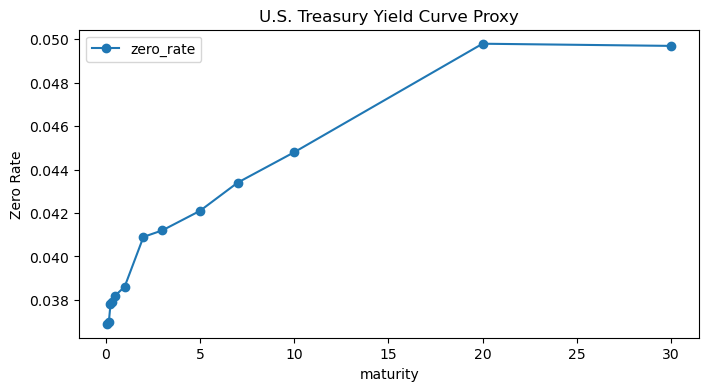

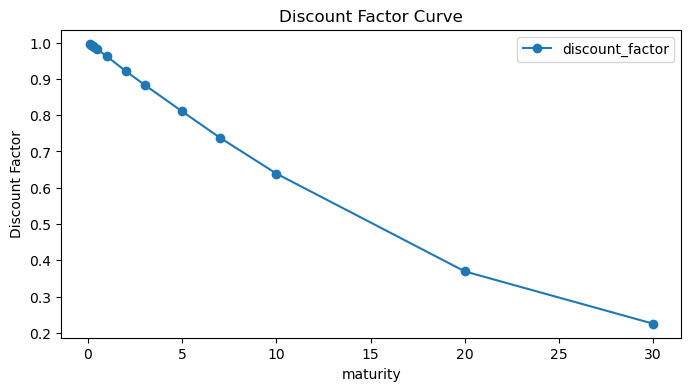

In [6]:
ax = curve_df.plot(x='maturity', y='zero_rate', marker='o', figsize=(8, 4), title='U.S. Treasury Yield Curve Proxy')
ax.set_ylabel('Zero Rate')
plt.show()

ax = discount_df.plot(x='maturity', y='discount_factor', marker='o', figsize=(8, 4), title='Discount Factor Curve')
ax.set_ylabel('Discount Factor')
plt.show()

## Representative Swaption on the Proxy Curve

This is not yet a fully vendor-calibrated swaption market snapshot. It is a market-validation bridge:

- the curve is market-connected through a public proxy source
- the sample trade remains a representative research trade
- this allows the pricing stack to be evaluated on top of a real observed rate environment

In [7]:
trade_df

,option_type,notional,expiry,tenor,strike,forward,annuity,black_vol,black_price
0,payer,10000000.0,2.0,5.0,0.04,0.045271,4.052214,0.2,319262.279853


## Interpretation

- This curve is a public-data U.S. Treasury proxy rather than a full dealer-grade SOFR swap curve.
- It is still useful for demonstrating how the pricing stack responds to a real observed rates regime.
- In the next validation stage, the project should add ATM swaption volatility and, if available, one real or manually curated smile slice.